In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [93]:
# Loaded CSV File and displayed first 5 rows as a DataFrame

real_estate_data = pd.read_csv("Data/real_estate_prices.csv")
real_estate_data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

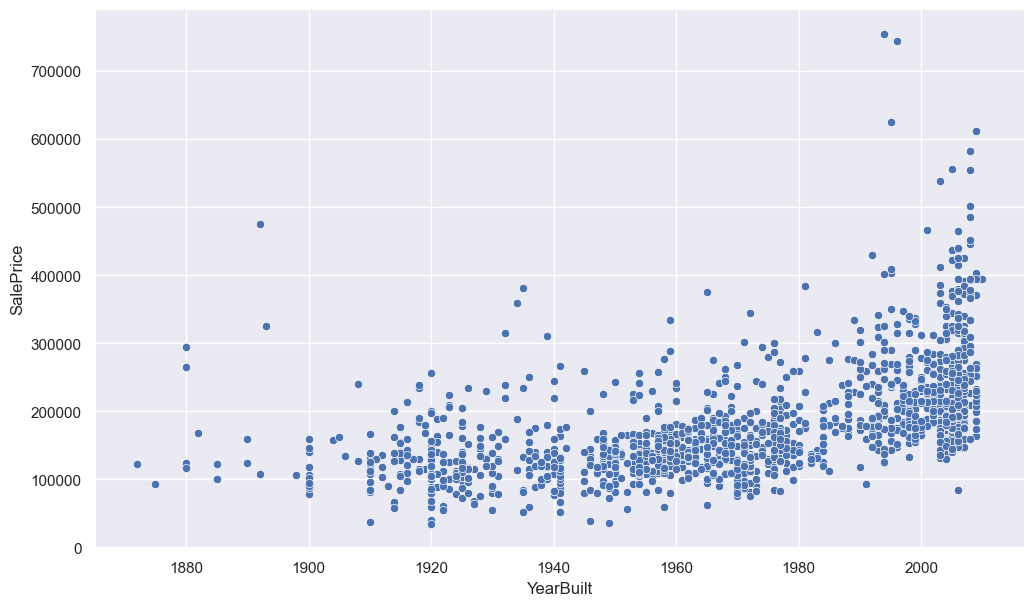

In [94]:
# Visualization

# Scatter Plot - Year Built vs Prices

sns.set(rc={"figure.figsize": (12, 7)})
sns.scatterplot(x = real_estate_data["YearBuilt"], y = real_estate_data["SalePrice"])

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

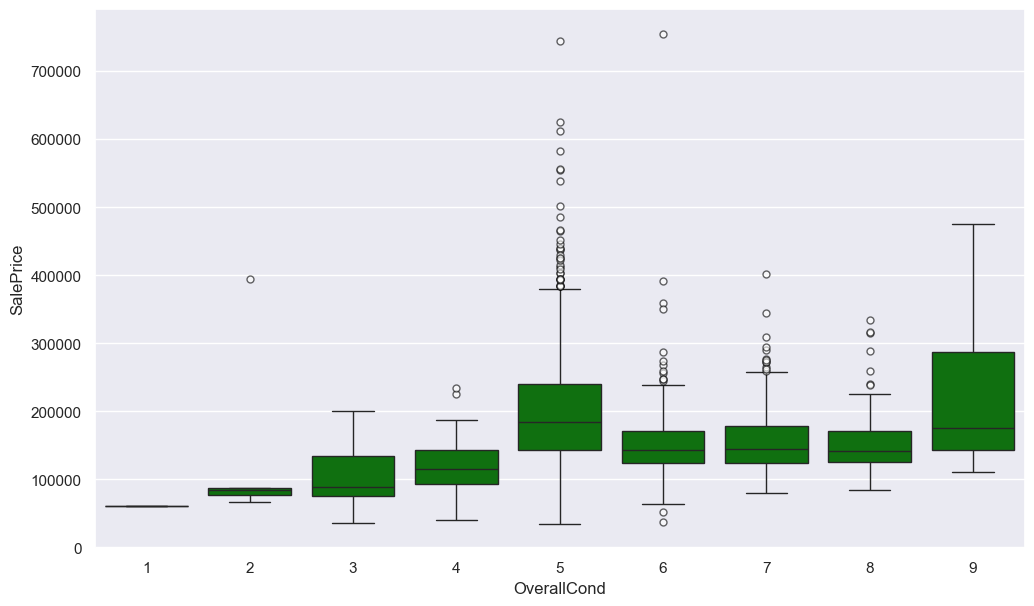

In [95]:
# Box Plot - Overall Condition vs Sale Price

# Singnificant outliers in the prices of houses rated at condition 5


sns.set(rc={"figure.figsize": (12, 7)})
sns.boxplot(x = real_estate_data["OverallCond"], y = real_estate_data["SalePrice"], color='green' ,flierprops={
        "marker": "o",
        "markersize": 5,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "alpha": 0.6
    })

<Axes: xlabel='BldgType', ylabel='SalePrice'>

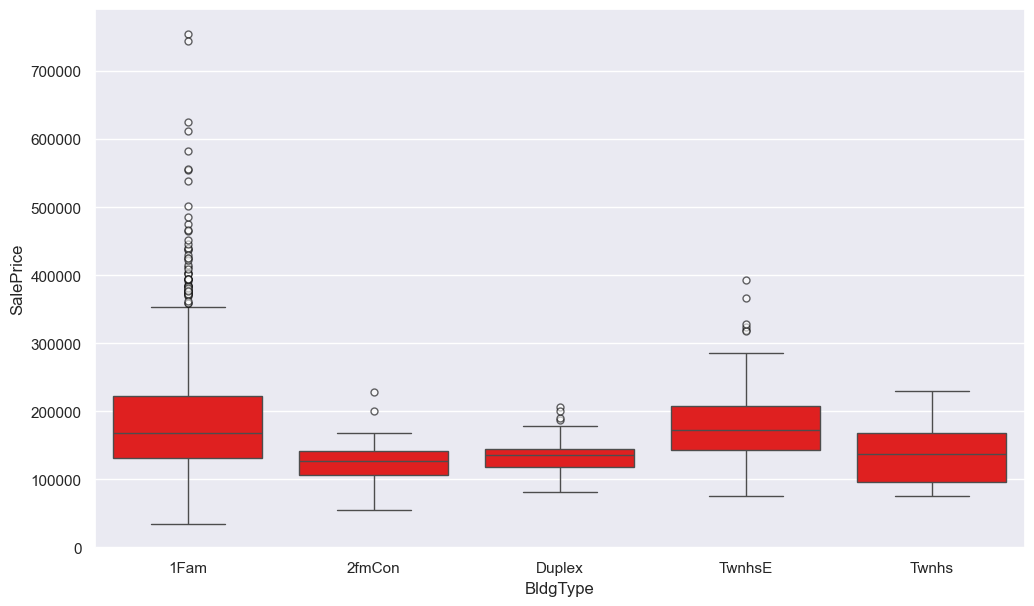

In [96]:
# Box Plot - Building Plot vs Box Prices

sns.boxplot(x = real_estate_data["BldgType"], y = real_estate_data["SalePrice"], color = "red", flierprops = {
        "marker": "o",
        "markersize": 5,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "alpha": 0.6 })

In [97]:
# Drop all missing SalePrices

real_estate_data = real_estate_data.dropna(subset=["SalePrice"])

# Input Values 

X = real_estate_data.drop(["Id", "SalePrice"], axis = 1)

# Output Value

y = real_estate_data["SalePrice"]
X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0


In [98]:
# Feature Engineering - Encoding all non-numerical data

X["MSZoning"] = X["MSZoning"].map(
    {
        "RL": 0,
        "RM": 1,
        "FV": 2,
        "RH": 3,
        "C (all)": 4
    })

X["LotConfig"] = X["LotConfig"].map(
    {
        "Inside": 0,
        "Corner": 1,
        "CulDSac": 2,
        "FR2": 3,
        "FR3": 4
    })
X["BldgType"] = X["BldgType"].map(
    {
        "1Fam": 0,
        "TwnhsE": 1,
        "Duplex": 2,
        "Twnhs": 3,
        "2fmCon": 4
    })
X["Exterior1st"] = X["Exterior1st"].map(
    {
        "VinylSd": 0,
        "MetalSd": 1,
        "HdBoard": 2,
        "Wd Sdng": 3,
        "Plywood": 4,
        "CemntBd": 5,
        "BrkFace": 6,
        "WdShing": 7,
        "AsbShng": 8,
        "Stucco": 9,
        "BrkComm": 10,
        "AsphShn": 11,
        "Stone": 12,
        "CBlock": 13,
        "ImStucc": 14
    })


X = X.fillna(-1) # Replace all NaN values with -1 

X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
0,60,0,8450,0,0,5,2003,2003,0,0.0,856.0
1,20,0,9600,3,0,8,1976,1976,1,0.0,1262.0
2,60,0,11250,0,0,5,2001,2002,0,0.0,920.0
3,70,0,9550,1,0,5,1915,1970,3,0.0,756.0
4,60,0,14260,3,0,5,2000,2000,0,0.0,1145.0


In [99]:
# Train the Model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
# Predicted Values 

y_predicted = model.predict(X_test)
y_predicted

array([192932.6193227 , 245312.59676055, 125625.10503429, 143554.4872665 ,
       254750.6691339 , 162908.20637502, 183748.78173848, 138423.82551599,
       110108.68884778, 145585.46197801, 121392.78545447, 143956.38452777,
       104800.38351633, 238682.92619017, 203023.3058871 , 183147.19992958,
       202359.07627877, 182084.84185505, 114767.83772739, 232785.57742612,
       164544.63785094, 198534.69960802, 196424.48993882, 161827.16783296,
       223602.9540316 , 224021.34011773, 227776.30417696, 121744.10333042,
       202762.29520483, 240043.63907807, 129932.41061864, 216649.57097056,
       219387.25089367, 133452.11263163, 253435.50463856, 160221.89846045,
       161768.59625998, 202264.36512493, 243206.514934  ,  62197.525403  ,
       114453.95285961, 203866.68670974, 143259.68671432, 288932.25570617,
       140858.56505992, 101407.85243045, 122262.14849918, 150531.62209194,
       291033.6143286 , 139763.59304373, 116939.0213407 , 210449.7098092 ,
       143686.64760979, 2

In [102]:
# Model Evaluation R2_Score

print(f"Model R2 Score: {(r2_score(y_test, y_predicted)) * 100} %")



Model Prediction Score: 59.95568642856244 %
